In [19]:
# Global Config

RUNNING_NEW_RENO = True
CWND_CSV_PATH = "/Users/samsikora/Desktop/Desktop/UBC/4.2/COSC_448/udp_client_server/log/data/cwnd_output.csv"
RTT_CSV_PATH = "/Users/samsikora/Deskt2op/Desktop/UBC/4.2/COSC_448/udp_client_server/log/data/rtt_output.csv"

# Congestion Control

Data sliced to start at index 26459 (First Event: TRIPLE_DUP_ACK)
LSTM fired 1 time(s).


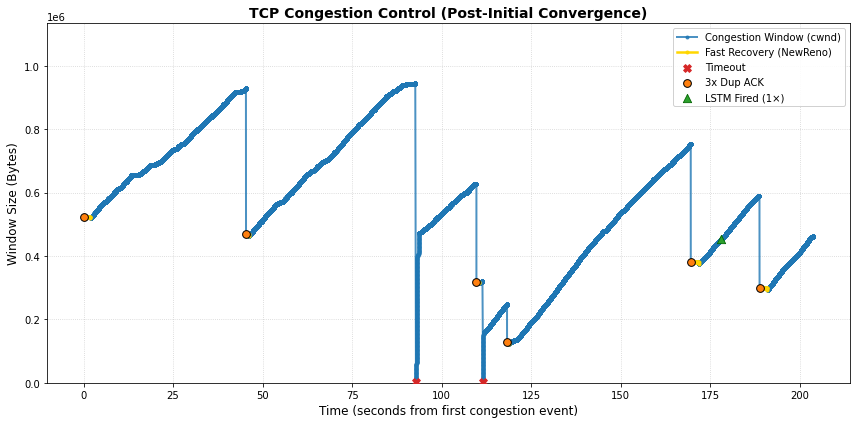

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the CSV data
column_names = ['Timestamp', 'Event', 'CWND', 'SSTHRESH']

try:
    df = pd.read_csv(CWND_CSV_PATH, names=column_names, header=None)
except FileNotFoundError:
    print("Error: cwnd_output.csv not found.")
    exit(1)

# 2. Clean and identify the "Start Point"
df['Timestamp'] = pd.to_numeric(df['Timestamp'], errors='coerce')
df['SSTHRESH'] = pd.to_numeric(df['SSTHRESH'], errors='coerce')

trigger_events = df.index[df['Event'].isin(['TRIPLE_DUP_ACK', 'TIMEOUT'])].tolist()
had_congestion = bool(trigger_events)

if had_congestion:
    start_idx = trigger_events[0]
    df = df.iloc[start_idx:].reset_index(drop=True)
    first_event_type = df.iloc[0]['Event']
    print(f"Data sliced to start at index {start_idx} (First Event: {first_event_type})")
else:
    print("No congestion events detected — plotting full transfer.")

if not df.empty:
    df['Timestamp'] = df['Timestamp'] - df['Timestamp'].iloc[0]

SENTINEL = 0xFFFFFFFF
df['SSTHRESH_plot'] = df['SSTHRESH'].where(df['SSTHRESH'] != SENTINEL)
df['CWND_plot'] = df['CWND'].where(df['CWND'] != SENTINEL)

# Fast Recovery (NewReno Partial ACKs) Flatlining
df['CWND_display'] = df['CWND_plot'].copy()

in_fast_recovery = False
fr_cwnd_value = None
fr_segments = []
current_fr_start = None

for idx, row in df.iterrows():
    event = row['Event']
    if event == 'TRIPLE_DUP_ACK':
        in_fast_recovery = True
        fr_cwnd_value = row['CWND_plot']
        current_fr_start = idx
    elif event == 'PARTIAL_ACK' and in_fast_recovery:
        df.at[idx, 'CWND_display'] = fr_cwnd_value
    elif event in ['ACK', 'TIMEOUT'] and in_fast_recovery:
        in_fast_recovery = False
        fr_segments.append((current_fr_start, idx))

if in_fast_recovery and current_fr_start is not None:
    fr_segments.append((current_fr_start, len(df) - 1))

# 3. Create the plot
plt.figure(figsize=(12, 6))

plt.plot(df['Timestamp'], df['CWND_display'], label='Congestion Window (cwnd)',
         color='#1f77b4', linewidth=2, marker='.', markersize=6, alpha=0.8)

for i, (start_idx, end_idx) in enumerate(fr_segments):
    segment = df.iloc[start_idx:end_idx+1]
    label = 'Fast Recovery (NewReno)' if i == 0 else None
    plt.plot(segment['Timestamp'], segment['CWND_display'],
             color='gold', linewidth=2.5, marker='.', markersize=6, alpha=1.0, label=label)

# 4. Highlight congestion events
timeouts = df[df['Event'] == 'TIMEOUT']
if not timeouts.empty:
    plt.scatter(timeouts['Timestamp'], timeouts['CWND_display'], color='#d62728',
                marker='X', s=60, label='Timeout', zorder=5)

triple_dups = df[df['Event'] == 'TRIPLE_DUP_ACK']
if not triple_dups.empty:
    plt.scatter(triple_dups['Timestamp'], triple_dups['CWND_display'], color='#ff7f0e',
                marker='o', s=60, label='3x Dup ACK', zorder=5, edgecolors='black')

# 5. LSTM fired markers — green triangles on the cwnd line
lstm_fired = df[df['Event'] == 'LSTM_FIRED']
if not lstm_fired.empty:
    plt.scatter(lstm_fired['Timestamp'], lstm_fired['CWND_display'], color='#2ca02c',
                marker='^', s=70, label=f'LSTM Fired ({len(lstm_fired)}×)', zorder=6,
                edgecolors='darkgreen', linewidths=0.8)
    print(f"LSTM fired {len(lstm_fired)} time(s).")
else:
    print("No LSTM_FIRED events in this run.")

# 6. Formatting
if had_congestion:
    title = 'TCP Congestion Control (Post-Initial Convergence)'
    xlabel = 'Time (seconds from first congestion event)'
else:
    title = 'TCP Congestion Control (No Congestion Events)'
    xlabel = 'Time (seconds from connection start)'

plt.title(title, fontsize=14, fontweight='bold')
plt.xlabel(xlabel, fontsize=12)
plt.ylabel('Window Size (Bytes)', fontsize=12)

if not df['CWND_display'].dropna().empty:
    ymax = df['CWND_display'].max() * 1.2
    plt.ylim(0, ymax)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', framealpha=0.9)
plt.tight_layout()

plt.savefig('utcp_sawtooth_fixed.png', dpi=300)
plt.show()

## RTT Time Series

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load RTT — columns: wallclock_epoch_s, seq, rtt_us, srtt_us, rttvar_us, rto_ms
rtt = pd.read_csv(
    RTT_CSV_PATH,
    names=['ts_epoch', 'seq', 'rtt_us', 'srtt_us', 'rttvar_us', 'rto_ms'],
    dtype={'ts_epoch': float, 'seq': int, 'rtt_us': int,
           'srtt_us': int, 'rttvar_us': int, 'rto_ms': int},
)

rtt_t0 = rtt['ts_epoch'].iloc[0]
rtt['t'] = rtt['ts_epoch'] - rtt_t0
rtt['rtt_ms'] = rtt['rtt_us'] / 1000
measured = rtt[rtt['rtt_us'] > 0].copy()

# Load congestion + LSTM events, aligned to RTT time origin
try:
    cwnd_raw = pd.read_csv(
        CWND_CSV_PATH,
        names=['Timestamp', 'Event', 'CWND', 'SSTHRESH'],
        header=None,
    )
    cwnd_raw['Timestamp'] = pd.to_numeric(cwnd_raw['Timestamp'], errors='coerce')
    cwnd_raw['t'] = cwnd_raw['Timestamp'] - rtt_t0

    cc_events   = cwnd_raw[cwnd_raw['Event'].isin(['TIMEOUT', 'TRIPLE_DUP_ACK'])]
    lstm_events = cwnd_raw[cwnd_raw['Event'] == 'LSTM_FIRED']
except FileNotFoundError:
    cc_events   = pd.DataFrame(columns=['t', 'Event'])
    lstm_events = pd.DataFrame(columns=['t', 'Event'])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.scatter(measured['t'], measured['rtt_ms'],
           s=14, color='#1f77b4', alpha=0.6, zorder=3, label='RTT (per ACK)')

# Congestion events — vertical lines
_timeout_labeled = False
_tripledup_labeled = False
for _, row in cc_events.iterrows():
    if row['Event'] == 'TIMEOUT':
        label = 'Timeout' if not _timeout_labeled else None
        ax.axvline(row['t'], color='#d62728', linestyle='--', linewidth=1.2,
                   alpha=0.8, label=label, zorder=4)
        _timeout_labeled = True
    elif row['Event'] == 'TRIPLE_DUP_ACK':
        label = '3x Dup ACK' if not _tripledup_labeled else None
        ax.axvline(row['t'], color='#ff7f0e', linestyle=':', linewidth=1.2,
                   alpha=0.8, label=label, zorder=4)
        _tripledup_labeled = True

# LSTM fired events — green dash-dot vertical lines
_lstm_labeled = False
for _, row in lstm_events.iterrows():
    label = f'LSTM Fired ({len(lstm_events)}×)' if not _lstm_labeled else None
    ax.axvline(row['t'], color='#2ca02c', linestyle='-.', linewidth=1.0,
               alpha=0.75, label=label, zorder=4)
    _lstm_labeled = True

ax.set_xlabel('Time (s from connection start)', fontsize=12)
ax.set_ylabel('Round-Trip Time (ms)', fontsize=12)
ax.set_ylim(bottom=0)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper right', framealpha=0.9)

plt.title('RTT Time Series — RFC 1323 Timestamp Measurements', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('rtt_timeseries.png', dpi=300)
plt.show()

print(f"Samples: {len(rtt)} total, {len(measured)} with RTT measurement")
print(f"RTT — min: {measured['rtt_ms'].min():.2f} ms  "
      f"mean: {measured['rtt_ms'].mean():.2f} ms  "
      f"max: {measured['rtt_ms'].max():.2f} ms")
print(f"Congestion events: {len(cc_events)} "
      f"({(cc_events['Event'] == 'TIMEOUT').sum()} timeouts, "
      f"{(cc_events['Event'] == 'TRIPLE_DUP_ACK').sum()} triple dup ACKs)")
print(f"LSTM fired: {len(lstm_events)} time(s)")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/samsikora/Deskt2op/Desktop/UBC/4.2/COSC_448/udp_client_server/log/data/rtt_output.csv'

# RTT Analysis

In [ ]:
import pandas as pd
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

rtt['timestamp'] = pd.to_datetime(rtt['ts_epoch'], unit='s')
rtt.set_index('timestamp', inplace=True)

rtt_binned = rtt['rtt_us'].resample('10ms').mean()
rtt_clean  = rtt_binned.interpolate(method='linear')

stl    = STL(rtt_clean, period=100, robust=True)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('STL Decomposition of Binned RTT Data', fontsize=16)
plt.tight_layout()

# Overlay congestion + LSTM events on every STL subplot
for ax in fig.axes:
    _timeout_labeled  = False
    _tripledup_labeled = False
    _lstm_labeled     = False

    for _, row in cc_events.iterrows():
        t_dt = pd.to_datetime(row['Timestamp'], unit='s')
        if row['Event'] == 'TIMEOUT':
            label = 'Timeout' if not _timeout_labeled else None
            ax.axvline(t_dt, color='#d62728', linestyle='--', linewidth=1.0,
                       alpha=0.7, label=label)
            _timeout_labeled = True
        elif row['Event'] == 'TRIPLE_DUP_ACK':
            label = '3x Dup ACK' if not _tripledup_labeled else None
            ax.axvline(t_dt, color='#ff7f0e', linestyle=':', linewidth=1.0,
                       alpha=0.7, label=label)
            _tripledup_labeled = True

    for _, row in lstm_events.iterrows():
        t_dt = pd.to_datetime(row['Timestamp'], unit='s')
        label = 'LSTM Fired' if not _lstm_labeled else None
        ax.axvline(t_dt, color='#2ca02c', linestyle='-.', linewidth=1.0,
                   alpha=0.7, label=label)
        _lstm_labeled = True

plt.show()

<Axes: ylabel='Frequency'>

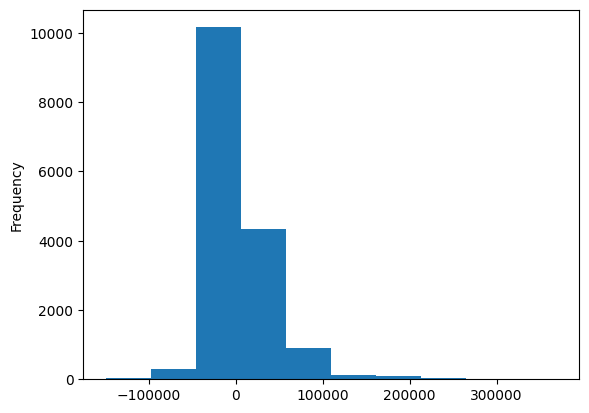

In [ ]:
result.resid.plot.hist()

In [ ]:
import matplotlib.pyplot as plt

threshold = 100000
anomalies_filter = result.resid.apply(lambda x: True if abs(x) > threshold else False)
anomalies = rtt_clean[anomalies_filter]

plt.figure(figsize=(14, 8))
plt.scatter(x=anomalies.index, y=anomalies, color="red", label="Anomalies", zorder=5)
plt.plot(rtt_clean.index, rtt_clean, color='blue', alpha=0.6, label='RTT (binned, µs)')

# Congestion events
_timeout_labeled  = False
_tripledup_labeled = False
for _, row in cc_events.iterrows():
    t_dt = pd.to_datetime(row['Timestamp'], unit='s')
    if row['Event'] == 'TIMEOUT':
        label = 'Timeout' if not _timeout_labeled else None
        plt.axvline(t_dt, color='#d62728', linestyle='--', linewidth=1.2,
                    alpha=0.8, label=label)
        _timeout_labeled = True
    elif row['Event'] == 'TRIPLE_DUP_ACK':
        label = '3x Dup ACK' if not _tripledup_labeled else None
        plt.axvline(t_dt, color='#ff7f0e', linestyle=':', linewidth=1.2,
                    alpha=0.8, label=label)
        _tripledup_labeled = True

# LSTM fired events
_lstm_labeled = False
for _, row in lstm_events.iterrows():
    t_dt = pd.to_datetime(row['Timestamp'], unit='s')
    label = 'LSTM Fired' if not _lstm_labeled else None
    plt.axvline(t_dt, color='#2ca02c', linestyle='-.', linewidth=1.2,
                alpha=0.8, label=label)
    _lstm_labeled = True

plt.title(f'RTT Anomalies (STL Residual > {threshold} µs)')
plt.xlabel('Time')
plt.ylabel('RTT (µs)')
plt.legend()
plt.show()